#### import uproot
import numpy as np
import matplotlib.pyplot as plt

# ROOT dosyasını output klasörü altından açıyoruz
dosya = uproot.open("/home/yusuf/geant4_work/Proje1_Giris/build/Veri_t0.root")

# Dosyanın içindeki veri ağaçlarının (Tree) isimlerini yazdırıyoruz
print(dosya.keys())

## Adım 2 Dosyayı Tek Seferde Okuma (Wildcard Yöntemi)

Diyelim ki Tree ismin "Scoring" çıktı (sen kendi çıktına göre değiştir). İşte Uproot'un gücü burada:

In [1]:
import uproot
import awkward as ak # Veriyi işlemek için gerekli kütüphane

# Dosya yolu kalıbı (Wildcard): veri_t*.root demek, t0'dan t11'e kadar hepsini al demek.
dosya_deseni = "/home/yusuf/geant4_work/Proje1_Giris/build/Veri_t*.root" 
# :Olaylar kısmı, her dosyadaki 'Scoring' isimli Tree'yi okuyacağımızı belirtir.

# concat (concatenate) komutu zincirleme yapar, hepsini uca ekler.
veriler = uproot.concatenate(dosya_deseni)


# Bakalım toplam kaç olay (event) birikmiş?
print(f"Toplam Olay Sayısı: {len(veriler)}")
print()
# Verilerin başlığına (dallarına) bakalım
print(veriler.fields)


Toplam Olay Sayısı: 45384

['Enerji_MeV']



Harika! Bak, gördün mü? Tek bir komutla 12 ayrı iş parçacığının ürettiği dağınık veriyi uproot.concatenate ile toparladık ve elimizde 50.000 olaylık (event) tertemiz bir veri paketi var.

Ekrana baktığımda şunu görüyorum:

    Tree İsmi: Olaylar (Güzel, Türkçe kullanmışsın, sevdim.)

    Dal (Branch) İsmi: Enerji_MeV

    Toplam Olay: 50,000

In [2]:
import numpy as np

# Veriyi daha rahat kullanmak için bir değişkene atayalım
enerjiler = veriler["Enerji_MeV"]

print(f"Minimum Enerji: {np.min(enerjiler)} MeV")
print(f"Maksimum Enerji: {np.max(enerjiler)} MeV")
print(f"Ortalama Enerji: {np.mean(enerjiler)} MeV")

# İlk 10 olaya bir göz atalım, bakalım mantıklı mı?
print("İlk 10 Olayın Enerjisi:", enerjiler[:10])

Minimum Enerji: 1.4478858143540663e-06 MeV
Maksimum Enerji: 1.3325000000000007 MeV
Ortalama Enerji: 1.064396969516241 MeV
İlk 10 Olayın Enerjisi: [1.33, 1.04, 0.356, 1.17, 1.17, 1.17, 1.33, 1.33, 1.17, 0.754]


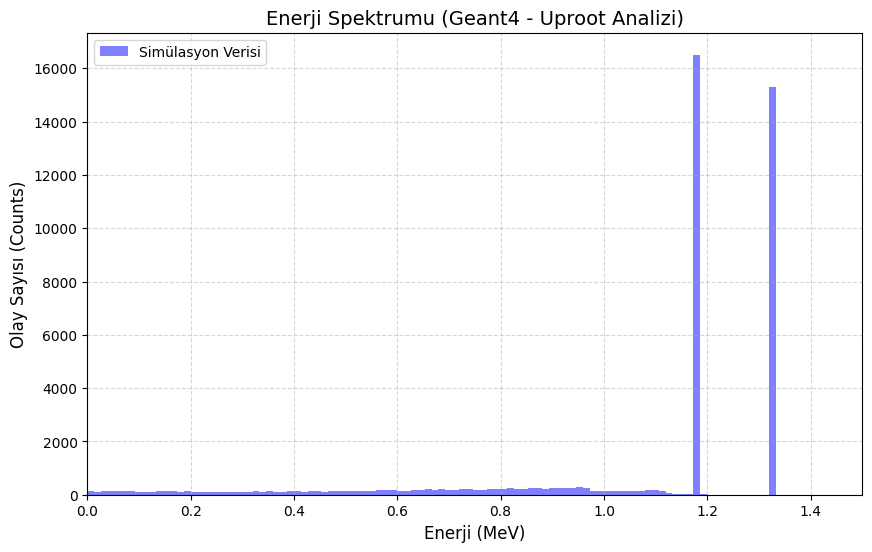

In [3]:
import matplotlib.pyplot as plt

# Histogram çizimi
plt.figure(figsize=(10, 6)) # Şekil boyutunu ayarla

# bins=100 demek, enerji aralığını 100 parçaya böl demek.
# range, histogramın x ekseni sınırlarını belirler. Otomatik de bırakabilirsin ama kontrollü olmak iyidir.
# log=True yaparsak y ekseni logaritmik olur, düşük ihtimalli olayları daha rahat görürüz. Şimdilik normal (lineer) bakalım.
plt.hist(enerjiler, bins=100, color='blue', alpha=0.5, label='Simülasyon Verisi')

plt.title("Enerji Spektrumu (Geant4 - Uproot Analizi)", fontsize=14)
plt.xlabel("Enerji (MeV)", fontsize=12)
plt.ylabel("Olay Sayısı (Counts)", fontsize=12)
plt.xlim(0,1.5)
plt.grid(True, linestyle='--', alpha=0.5) # Izgara çizgileri ekle
plt.legend()

plt.show()

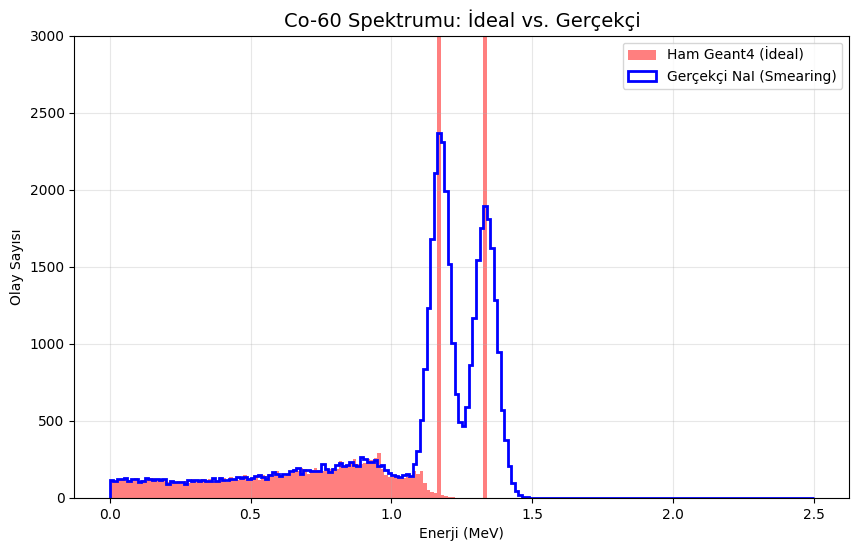

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Ham veriyi alalım
ham_enerji = veriler["Enerji_MeV"]

# 2. Bulanıklaştırma (Smearing) Faktörü
# NaI dedektörleri için genelde %5-7 civarıdır.
# Sigma = Enerji * çözünürlük_katsayısı
# Burada basitçe her enerjiye %3 rastgelelik ekliyoruz.
sigma = ham_enerji * 0.03 

# 3. Her bir enerji değerine rastgele Gauss gürültüsü ekle
# np.random.normal(merkez, genislik, adet)
gercekci_enerji = np.random.normal(ham_enerji, sigma)

# --- ÇİZİM ---
plt.figure(figsize=(10, 6))

# Önce senin saf Geant4 verini çizelim (İnce çizgiler)
plt.hist(ham_enerji, bins=200, range=(0, 2.5), alpha=0.5, label='Ham Geant4 (İdeal)', color='red')

# Şimdi üzerine "Gerçekçi" veriyi çizelim (Mavi, kalın)
plt.hist(gercekci_enerji, bins=200, range=(0, 2.5), histtype='step', linewidth=2, label='Gerçekçi NaI (Smearing)', color='blue')

plt.title("Co-60 Spektrumu: İdeal vs. Gerçekçi", fontsize=14)
plt.xlabel("Enerji (MeV)")
plt.ylabel("Olay Sayısı")
plt.ylim(0,3000)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

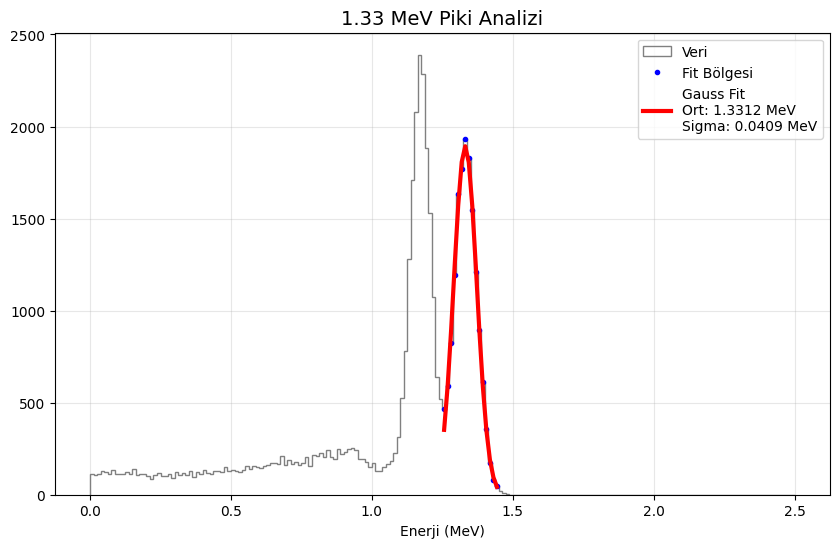

--- ANALİZ SONUCU ---
Pik Merkezi: 1.33119 MeV
Sigma Değeri: 0.04087 MeV
Enerji Çözünürlüğü (FWHM%): %7.23


In [11]:
from scipy.optimize import curve_fit

# 1. Önce veriyi Histogram verisine (sayısal diziye) dökmemiz lazım (çizdirmeden)
counts, bin_edges = np.histogram(gercekci_enerji, bins=200, range=(0, 2.5))

# Bin merkezlerini (x ekseni) hesaplayalım
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 2. Fit yapmak istediğimiz bölgeyi seçelim (1.33 MeV civarı)
# Sadece 1.25 ile 1.45 MeV arasını alalım
mask = (bin_centers > 1.25) & (bin_centers < 1.45)
x_fit = bin_centers[mask]
y_fit = counts[mask]

# 3. Gauss Fonksiyonumuzu Tanımlayalım
def gauss_function(x, amplitude, mean, sigma):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))

# Başlangıç tahminlerimiz (Fit'in sapıtmaması için ipucu veriyoruz)
tahminler = [max(y_fit), 1.33, 0.05] # Yükseklik, Ortalama, Genişlik

# 4. Ve BÜYÜLÜ AN: Eğriyi Uydur!
popt, pcov = curve_fit(gauss_function, x_fit, y_fit, p0=tahminler)

amplitude_fit, mean_fit, sigma_fit = popt

# --- SONUÇLARI ÇİZELİM ---
plt.figure(figsize=(10, 6))
# Orijinal veriyi çiz
plt.hist(gercekci_enerji, bins=200, range=(0, 2.5), histtype='step', color='gray', label='Veri')
# Fit bölgesini çiz
plt.plot(x_fit, y_fit, 'b.', label='Fit Bölgesi')
# Uydurduğumuz eğriyi çiz
plt.plot(x_fit, gauss_function(x_fit, *popt), 'r-', linewidth=3, label=f'Gauss Fit\nOrt: {mean_fit:.4f} MeV\nSigma: {sigma_fit:.4f} MeV')

plt.title("1.33 MeV Piki Analizi", fontsize=14)
plt.xlabel("Enerji (MeV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Çözünürlük Hesabı (FWHM = 2.355 * Sigma)
FWHM = 2.355 * sigma_fit
cozunurluk = (FWHM / mean_fit) * 100
print(f"--- ANALİZ SONUCU ---")
print(f"Pik Merkezi: {mean_fit:.5f} MeV")
print(f"Sigma Değeri: {sigma_fit:.5f} MeV")
print(f"Enerji Çözünürlüğü (FWHM%): %{cozunurluk:.2f}")

--- DEDEKTÖR KALİTE RAPORU ---
Pik Merkezi (Mu): 1.3314 MeV
Pik Genişliği (Sigma): 0.0412 MeV
Enerji Çözünürlüğü (FWHM%): %7.29


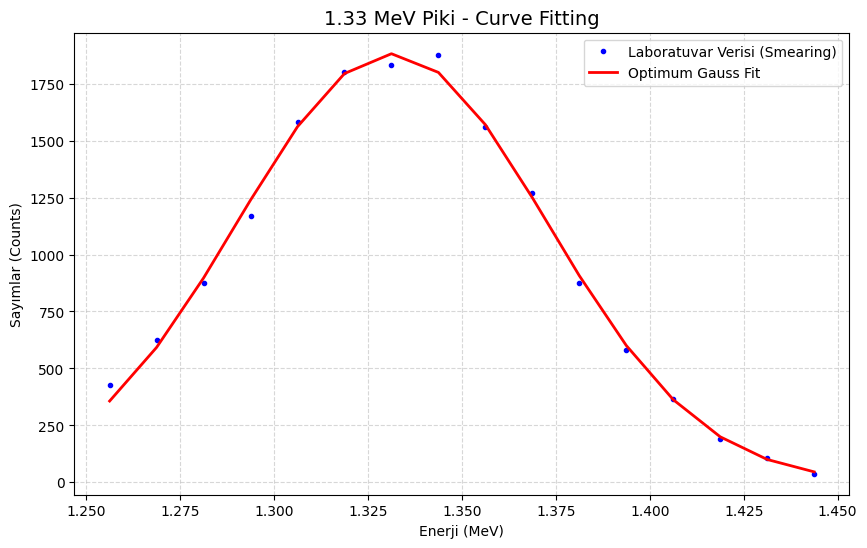

In [18]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# (Ön Hazırlık: Daha önce elimizdeki veriyi çizim için histograma dökmüştük, 
# x ekseni için bin merkezlerini, y ekseni için sayımları alıyoruz.)
counts, bin_edges = np.histogram(gercekci_enerji, bins=200, range=(0, 2.5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ==========================================
# 1. ADIM: Bölgeyi Kesmek (Maskeleme)
# ==========================================
# Sadece 1.25 MeV ile 1.45 MeV arasını kesip alıyoruz.
maskeleme = (bin_centers > 1.25) & (bin_centers < 1.45)
x_kesilmis = bin_centers[maskeleme]
y_kesilmis = counts[maskeleme]

# ==========================================
# 2. ADIM: Fonksiyonu Tanımlamak (Doğanın Dili)
# ==========================================
# Gauss çan eğrimizin matematiksel formülünü yazıyoruz.
def gauss_fonksiyonu(x, genlik, merkez, sigma):
    return genlik * np.exp(-(x - merkez)**2 / (2 * sigma**2))

# ==========================================
# 3. ADIM: Başlangıç Tahminleri (Kılavuzluk)
# ==========================================
# Sırasıyla: [Tahmini Genlik, Tahmini Merkez, Tahmini Genişlik(Sigma)]
ilk_tahminler = [max(y_kesilmis), 1.33, 0.05]

# ==========================================
# 4. ADIM: Optimizasyon (Fit İşlemi)
# ==========================================
# curve_fit fonksiyonu bize iki şey döndürür:
# popt: Bulunan en mükemmel parametreler dizisi (genlik, merkez, sigma)
# pcov: Hata/Kovaryans matrisi (şu an bununla işimiz yok)
popt, pcov = curve_fit(gauss_fonksiyonu, x_kesilmis, y_kesilmis, p0=ilk_tahminler)

# Bulunan parametreleri tek tek değişkenlere atayalım
en_iyi_genlik = popt[0]
en_iyi_merkez = popt[1]
en_iyi_sigma = abs(popt[2]) # Genişlik eksi çıkmasın diye mutlak değer alıyoruz

# ==========================================
# FİZİKSEL HESAPLAMA: ÇÖZÜNÜRLÜK (FWHM)
# ==========================================
FWHM = 2.355 * en_iyi_sigma
cozunurluk_yuzdesi = (FWHM / en_iyi_merkez) * 100

print("--- DEDEKTÖR KALİTE RAPORU ---")
print(f"Pik Merkezi (Mu): {en_iyi_merkez:.4f} MeV")
print(f"Pik Genişliği (Sigma): {en_iyi_sigma:.4f} MeV")
print(f"Enerji Çözünürlüğü (FWHM%): %{cozunurluk_yuzdesi:.2f}")

# --- EKRANA ÇİZDİRME (GÖZÜMÜZLE GÖRELİM) ---
plt.figure(figsize=(10, 6))
# Sadece kestiğimiz bölgedeki ham veriyi nokta nokta çizelim
plt.plot(x_kesilmis, y_kesilmis, 'b.', label='Laboratuvar Verisi (Smearing)')

# Şimdi bilgisayarın uydurduğu kusursuz Gauss eğrisini çizelim
plt.plot(x_kesilmis, gauss_fonksiyonu(x_kesilmis, *popt), 'r-', linewidth=2, label='Optimum Gauss Fit')

plt.title("1.33 MeV Piki - Curve Fitting", fontsize=14)
plt.xlabel("Enerji (MeV)")
plt.ylabel("Sayımlar (Counts)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()